In [1]:
import wfdb
import os
import numpy as np
import pandas as pd

NORMAL_BEATS = ['N', 'L', 'R', 'e', 'j', '.']
ARRHYTHMIC_BEATS = ['A', 'a', 'J', 'S', 'V', 'E', 'F']
VALID_BEATS = NORMAL_BEATS + ARRHYTHMIC_BEATS

annotation_folder = 'mit-bih-arrhythmia-database-1.0.0'

selected_patients = [
    '215','213','209','203','210','116','222','233',
    '118','223','221','214','200','228','201','208',
    '119','207','106'
]

results = []

for record in selected_patients:
    try:
        ann = wfdb.rdann(os.path.join(annotation_folder, record), 'atr')
    except:
        print(f"Skipping {record}")
        continue

    # Keep only true beat annotations
    beat_mask = [s in VALID_BEATS for s in ann.symbol]
    beat_samples = ann.sample[beat_mask]
    beat_symbols = np.array(ann.symbol)[beat_mask]

    # Compute inter-beat intervals
    ibi = np.diff(beat_samples)

    for i in range(1, len(beat_symbols)):
        prev_sym = beat_symbols[i-1]
        curr_sym = beat_symbols[i]
        interval = beat_samples[i] - beat_samples[i-1]

        if prev_sym in NORMAL_BEATS and curr_sym in NORMAL_BEATS:
            transition = 'N→N'
        elif prev_sym in NORMAL_BEATS and curr_sym in ARRHYTHMIC_BEATS:
            transition = 'N→A'
        elif prev_sym in ARRHYTHMIC_BEATS and curr_sym in ARRHYTHMIC_BEATS:
            transition = 'A→A'
        else:
            transition = 'A→N'

        results.append([record, transition, interval])

df = pd.DataFrame(
    results,
    columns=['Record', 'Transition', 'BeatInterval_samples']
)


In [2]:
summary = (
    df.groupby('Transition')['BeatInterval_samples']
      .agg(['mean', 'std', 'min', 'median', 'count'])
      .reset_index()
)

print(summary)


  Transition        mean         std  min  median  count
0        A→A  181.743468   64.729021   90   169.0   1684
1        A→N  324.068683   92.719320  116   304.0   6843
2        N→A  194.627394  434.820424  105   189.0   6841
3        N→N  258.460543   76.508705  103   253.0  32846


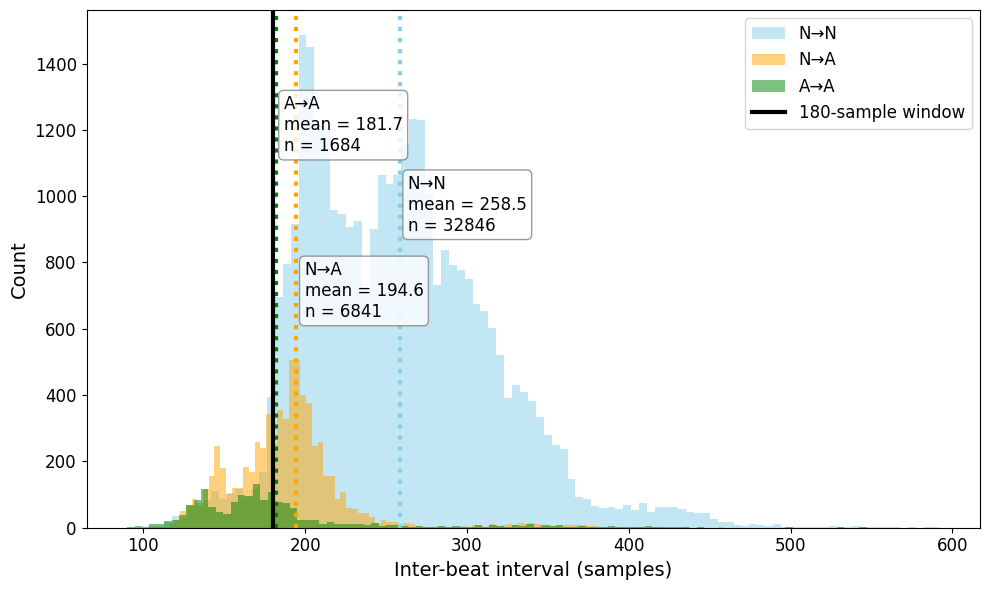

In [5]:
import matplotlib.pyplot as plt

stats = summary.set_index('Transition')

MAX_INTERVAL = 600  # samples (~1.7 s)

df_clipped = df[df['BeatInterval_samples'] <= MAX_INTERVAL]

# Increase figure size for clarity
plt.figure(figsize=(10, 6))

ymax = 0  # track max height for text placement

# define small offsets for each transition
offset_map = {'N→N': -200, 'N→A': -460, 'A→A': 40}

# define colors for each transition
color_map = {'N→N': 'skyblue', 'N→A': 'orange', 'A→A': 'green'}

for transition in ['N→N', 'N→A', 'A→A']:
    data = df_clipped[df_clipped['Transition'] == transition]['BeatInterval_samples']
    counts, bins, _ = plt.hist(
        data, bins=100, alpha=0.5, label=transition, color=color_map[transition]
    )
    ymax = max(ymax, counts.max())

    mean_val = stats.loc[transition, 'mean']
    count_val = int(stats.loc[transition, 'count'])

    # Mean line (same color as histogram)
    plt.axvline(mean_val, linestyle=':', linewidth=3, color=color_map[transition])

    # Text annotation with bigger font
    plt.text(
        mean_val + 5, ymax * 0.85 + offset_map[transition],
        f'{transition}\n'
        f'mean = {mean_val:.1f}\n'
        f'n = {count_val}',
        fontsize=12,  # larger font
        verticalalignment='top',
        bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray', boxstyle='round,pad=0.3')
    )

# 180-sample window (bolder and thicker)
plt.axvline(180, linestyle='-', linewidth=3, color='black', label='180-sample window')

plt.xlabel('Inter-beat interval (samples)', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(fontsize=12)
plt.tight_layout()

# Save figure at 300 dpi
plt.savefig('inter_beat_interval_distribution.png', dpi=300)
plt.show()
